In [3]:
from google.colab import files

uploaded = files.upload()


Saving test.tsv to test.tsv
Saving train.tsv to train.tsv
Saving valid.tsv to valid.tsv


In [4]:
import pandas as pd

train_df = pd.read_csv("train.tsv", sep="\t", header=None)
valid_df = pd.read_csv("valid.tsv", sep="\t", header=None)
test_df = pd.read_csv("test.tsv", sep="\t", header=None)

print("Train Shape:", train_df.shape)
print("Validation Shape:", valid_df.shape)
print("Test Shape:", test_df.shape)

train_df.head()

Train Shape: (10240, 14)
Validation Shape: (1284, 14)
Test Shape: (1267, 14)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,2635.json,false,Says the Annies List political group supports ...,abortion,dwayne-bohac,State representative,Texas,republican,0.0,1.0,0.0,0.0,0.0,a mailer
1,10540.json,half-true,When did the decline of coal start? It started...,"energy,history,job-accomplishments",scott-surovell,State delegate,Virginia,democrat,0.0,0.0,1.0,1.0,0.0,a floor speech.
2,324.json,mostly-true,"Hillary Clinton agrees with John McCain ""by vo...",foreign-policy,barack-obama,President,Illinois,democrat,70.0,71.0,160.0,163.0,9.0,Denver
3,1123.json,false,Health care reform legislation is likely to ma...,health-care,blog-posting,NaN,NaN,none,7.0,19.0,3.0,5.0,44.0,a news release
4,9028.json,half-true,The economic turnaround started at the end of ...,"economy,jobs",charlie-crist,NaN,Florida,democrat,15.0,9.0,20.0,19.0,2.0,an interview on CNN


DATASET:-

In [5]:
liar_df = train_df[[1,2]].copy()

liar_df.columns = ["label","statement"]

print(liar_df.head())
print("\nShape:", liar_df.shape)

         label                                          statement
0        false  Says the Annies List political group supports ...
1    half-true  When did the decline of coal start? It started...
2  mostly-true  Hillary Clinton agrees with John McCain "by vo...
3        false  Health care reform legislation is likely to ma...
4    half-true  The economic turnaround started at the end of ...

Shape: (10240, 2)


In [6]:
liar_df.isnull().sum()

,0
label,0
statement,0


Label Distribution

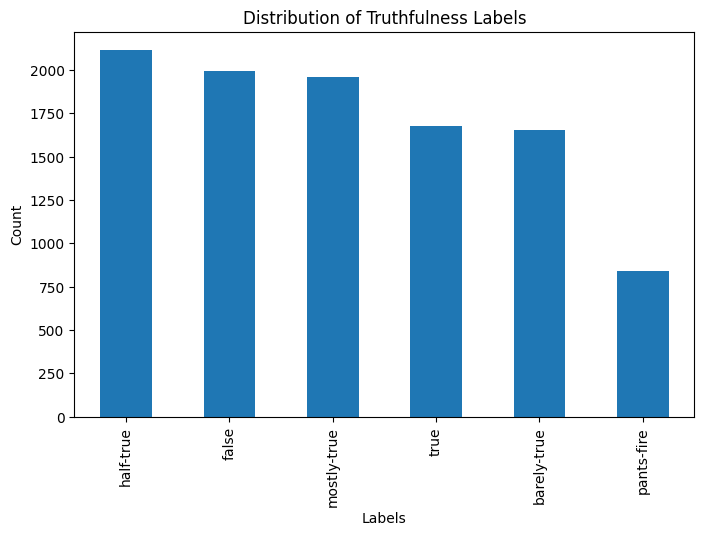

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
liar_df["label"].value_counts().plot(kind="bar")

plt.title("Distribution of Truthfulness Labels")
plt.xlabel("Labels")
plt.ylabel("Count")

plt.show()

Statement Length Analysis

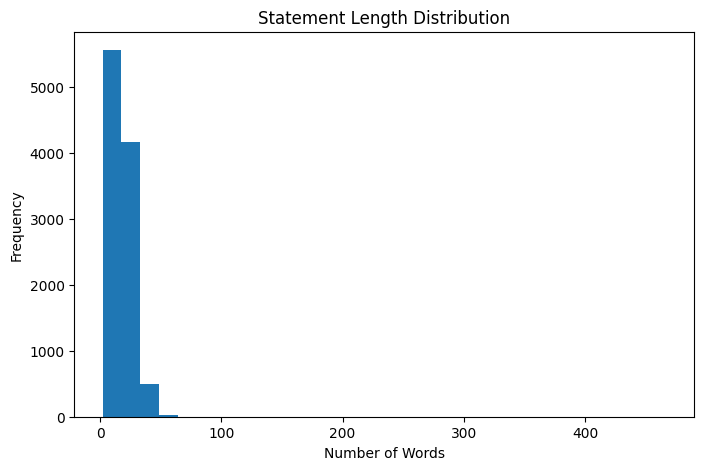

In [8]:
liar_df["length"] = liar_df["statement"].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(8,5))

plt.hist(liar_df["length"], bins=30)

plt.title("Statement Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

Binary Classification Conversion

In [9]:
fake_labels = ["false","barely-true","pants-fire"]

liar_df["label"] = liar_df["label"].apply(
    lambda x: 0 if x in fake_labels else 1
)

liar_df["label"].value_counts()

,count
label,
1,5752
0,4488


Text Preprocessing

In [10]:
import re

def clean_text(text):

    text = str(text).lower()

    text = re.sub(r"http\S+","",text)

    text = re.sub(r"[^a-zA-Z ]","",text)

    return text

liar_df["statement"] = liar_df["statement"].apply(clean_text)

liar_df.head()

,label,statement,length
0,0,says the annies list political group supports ...,11
1,1,when did the decline of coal start it started ...,24
2,1,hillary clinton agrees with john mccain by vot...,19
3,0,health care reform legislation is likely to ma...,12
4,1,the economic turnaround started at the end of ...,10


In [11]:
liar_df["label"].value_counts()

,count
label,
1,5752
0,4488


Tokenization

In [37]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_WORDS = 5000
MAX_LEN = 50

tokenizer = Tokenizer(
    num_words=MAX_WORDS,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(liar_df["statement"])

sequences = tokenizer.texts_to_sequences(
    liar_df["statement"]
)

X = pad_sequences(
    sequences,
    maxlen=MAX_LEN,
    padding="post"
)

y = liar_df["label"]

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (10240, 50)
y Shape: (10240,)


Train-Test Split

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(8192, 100)
(2048, 100)


Bi-LSTM Model

In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    Bidirectional,
    LSTM,
    Dense,
    Dropout
)

model = Sequential()

model.add(
    Embedding(
        input_dim=10000,
        output_dim=128
    )
)

model.add(
    Bidirectional(
        LSTM(64)
    )
)

model.add(
    Dropout(0.6)
)

model.add(
    Dense(
        32,
        activation="relu"
    )
)

model.add(
    Dropout(0.5)
)

model.add(
    Dense(
        1,
        activation="sigmoid"
    )
)

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [23]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

Training

In [30]:
history = model.fit(
    X_train,
    y_train,
    epochs=3,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/3
205/205 ━━━━━━━━━━━━━━━━━━━━ 36s 176ms/step - accuracy: 0.9876 - loss: 0.0417 - val_accuracy: 0.5729 - val_loss: 2.6031
Epoch 2/3
205/205 ━━━━━━━━━━━━━━━━━━━━ 28s 138ms/step - accuracy: 0.9892 - loss: 0.0348 - val_accuracy: 0.5570 - val_loss: 2.8586
Epoch 3/3
205/205 ━━━━━━━━━━━━━━━━━━━━ 41s 138ms/step - accuracy: 0.9873 - loss: 0.0389 - val_accuracy: 0.5479 - val_loss: 3.2742


EVALUATION


In [31]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

64/64 ━━━━━━━━━━━━━━━━━━━━ 6s 81ms/step
Accuracy: 0.55712890625
Precision: 0.6048317515099223
Recall: 0.6095652173913043
F1 Score: 0.6071892594196622

Classification Report
              precision    recall  f1-score   support

           0       0.49      0.49      0.49       898
           1       0.60      0.61      0.61      1150

    accuracy                           0.56      2048
   macro avg       0.55      0.55      0.55      2048
weighted avg       0.56      0.56      0.56      2048



Confusion Matrix

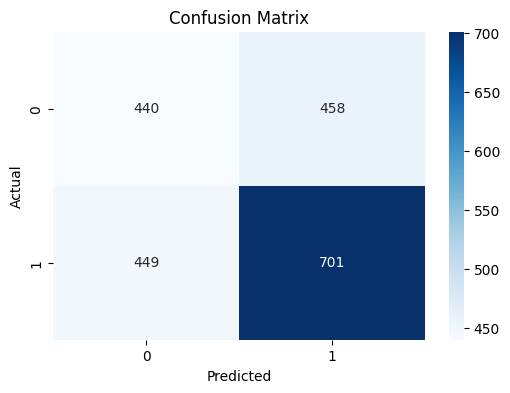

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
ACCURACY GRAPH

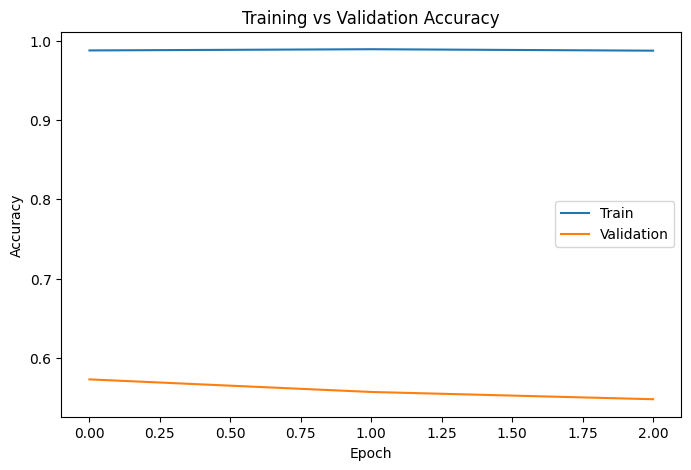

In [33]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])

plt.show()

Loss Graph

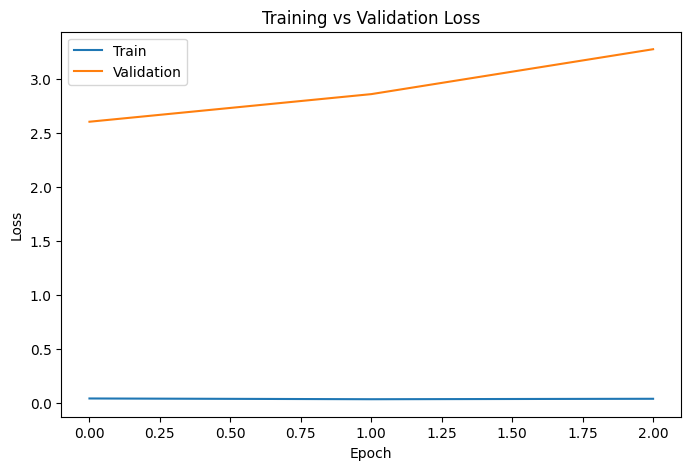

In [34]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])

plt.show()

In [35]:
model.save("fake_news_lstm.keras")

PREDICTION

In [39]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

sample = ["The government announced a new economic policy today"]

seq = tokenizer.texts_to_sequences(sample)

print(seq)

seq = pad_sequences(seq, maxlen=100)

prediction = model.predict(seq)

print("Probability:", prediction[0][0])

if prediction[0][0] > 0.5:
    print("Likely Real News")
else:
    print("Likely Fake News")

[[2, 84, 1205, 6, 54, 304, 515, 150]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 705ms/step
Probability: 0.081464075
Likely Fake News
